# Walmart_Store Sales Forecasting

Step 1: Load all datasets
Step 2: Merge datasets
Step 3: Data cleaning
Step 4: Feature engineering
Step 5: Define X and y 
Step 6: Split by time → Train / Test
Step 7: Train XGBoo
Step 8: Evaluate model

## 1. EDA

### 1. Import Features Dataset

In [1]:
import pandas as pd
# import feature dataset 
df_feature = pd.read_csv('features.csv')
# Check the head with the feature dataset
print(df_feature.shape)
df_feature.head(10)

(8190, 12)


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,5/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,5/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
5,1,12/03/2010,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False
6,1,19/03/2010,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,False
7,1,26/03/2010,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,False
8,1,2/04/2010,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,False
9,1,9/04/2010,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,False


In [2]:
# Check the dataset basic info

# Check the size of the dataset (total rows and columns)
print(f"The dataset has {df_feature.shape[0]} rows and {df_feature.shape[1]} columns.")

# View column names, data types, and check for missing values
print(df_feature.info())

The dataset has 8190 rows and 12 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB
None


### 2. Import Stores Dataset

In [3]:
# Import sales dataset
df_stores = pd.read_csv('stores.csv')
# Check the head with the feature dataset
print(df_stores.shape)
df_stores.head(6)

(45, 3)


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505


In [4]:
# Merge two datasets with 'store'
df_merged_1 = pd.merge(df_feature, df_stores, on='Store', how='inner')

print(df_merged_1.shape)
df_merged_1.head()

(8190, 14)


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,1,5/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,5/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [5]:
# Check the new dataset info
df_merged_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
 12  Type          8190 non-null   object 
 13  Size          8190 non-null   int64  
dtypes: bool(1), float64(9), int64(2), object(2)
memory usage: 839.9+ KB


### 3.Import Train Dataset 

In [6]:
# Import train dataset 
df_train = pd.read_csv('train.csv')
df_train

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [8]:
# check if the two data have the same store column
print(df_merged_1.columns)
print(df_train.columns)

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday', 'Type', 'Size'],
      dtype='object')
Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')


In [9]:
# Check if the data are in the right format 
print(df_merged_1['Date'].dtype)
print(df_train['Date'].dtype)

print(df_merged_1['Date'].head())
print(df_train['Date'].head())

object
object
0     5/02/2010
1    12/02/2010
2    19/02/2010
3    26/02/2010
4     5/03/2010
Name: Date, dtype: object
0    2010-02-05
1    2010-02-12
2    2010-02-19
3    2010-02-26
4    2010-03-05
Name: Date, dtype: object


In [10]:
df_merged_1['Date'] = pd.to_datetime(df_merged_1['Date'], format='%d/%m/%Y').dt.strftime('%d/%m/%Y')
df_train['Date'] = pd.to_datetime(df_train['Date'], format='%Y-%m-%d').dt.strftime('%d/%m/%Y')

#df_merged_1['Date'] = pd.to_datetime(df_merged_1['Date'], format='%d/%m/%Y')
#df_train['Date'] = pd.to_datetime(df_train['Date'], format='%Y-%m-%d')

In [11]:
# Merge the two dataset into the final dataset
df_merged_final = pd.merge(df_merged_1, df_train, on=['Store', 'Date'], how='inner')

print(df_merged_final.shape)
df_merged_final.head()

(421570, 17)


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_x,Type,Size,Dept,Weekly_Sales,IsHoliday_y
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315,1,24924.50,False
1,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315,2,50605.27,False
2,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315,3,13740.12,False
3,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315,4,39954.04,False
4,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315,5,32229.38,False


In [12]:
# Check the final dataset info
df_merged_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Date          421570 non-null  object 
 2   Temperature   421570 non-null  float64
 3   Fuel_Price    421570 non-null  float64
 4   MarkDown1     150681 non-null  float64
 5   MarkDown2     111248 non-null  float64
 6   MarkDown3     137091 non-null  float64
 7   MarkDown4     134967 non-null  float64
 8   MarkDown5     151432 non-null  float64
 9   CPI           421570 non-null  float64
 10  Unemployment  421570 non-null  float64
 11  IsHoliday_x   421570 non-null  bool   
 12  Type          421570 non-null  object 
 13  Size          421570 non-null  int64  
 14  Dept          421570 non-null  int64  
 15  Weekly_Sales  421570 non-null  float64
 16  IsHoliday_y   421570 non-null  bool   
dtypes: bool(2), float64(10), int64(3), object(2)
mem

In [13]:
# Check the column 'holiday' if contain the same value
print((df_merged_final['IsHoliday_x'] == df_merged_final['IsHoliday_y']).all())

True


In [14]:
# Delete the double Holiday column
df_merged_final = df_merged_final.drop(columns=['IsHoliday_y'])
df_merged_final = df_merged_final.rename(columns={'IsHoliday_x': 'IsHoliday'})


### 4. Merge the final dataset

In [15]:
# Check the final dataset 
df_merged_final 

# Download the dataset to check 
df_merged_final.to_csv('df_merged_final.csv', index=False)

In [16]:
df_merged_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Date          421570 non-null  object 
 2   Temperature   421570 non-null  float64
 3   Fuel_Price    421570 non-null  float64
 4   MarkDown1     150681 non-null  float64
 5   MarkDown2     111248 non-null  float64
 6   MarkDown3     137091 non-null  float64
 7   MarkDown4     134967 non-null  float64
 8   MarkDown5     151432 non-null  float64
 9   CPI           421570 non-null  float64
 10  Unemployment  421570 non-null  float64
 11  IsHoliday     421570 non-null  bool   
 12  Type          421570 non-null  object 
 13  Size          421570 non-null  int64  
 14  Dept          421570 non-null  int64  
 15  Weekly_Sales  421570 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


## 2. Data Processing

#### Clean the data

In [17]:
# ============================================
# 1. Check for Missing Values
# ============================================
print("=== Missing Values Check ===")
missing = df_merged_final.isnull().sum()
missing_pct = (missing / len(df_merged_final) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Percentage(%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values Check ===
           Missing Count  Missing Percentage(%)
MarkDown1         270889                  64.26
MarkDown2         310322                  73.61
MarkDown3         284479                  67.48
MarkDown4         286603                  67.98
MarkDown5         270138                  64.08


In [18]:
# Handling with missing value with markdown

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df_merged_final[markdown_cols] = df_merged_final[markdown_cols].fillna(0)


In [19]:
# ============================================
# 2. Check for Duplicate Rows
# ============================================
print("\n=== Duplicate Rows Check ===")
duplicates = df_merged_final.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


=== Duplicate Rows Check ===
Number of duplicate rows: 0


In [20]:
# ============================================
# 3. Check Data Types
# ============================================
print("\n=== Data Types Check ===")
print(df_merged_final.dtypes)


=== Data Types Check ===
Store             int64
Date             object
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
Type             object
Size              int64
Dept              int64
Weekly_Sales    float64
dtype: object


In [21]:
# ============================================
# 4. Check for Outliers (Negative Sales = Returns)
# ============================================
print("\n=== Outliers Check ===")
negative_sales = (df_merged_final['Weekly_Sales'] < 0).sum()
print(f"Number of negative Weekly_Sales: {negative_sales}")

# Remove negative sales (exclude return transactions)
df_merged_final = df_merged_final[df_merged_final['Weekly_Sales'] >= 0]
print(f"Remaining rows after removing negatives: {df_merged_final.shape[0]}")


=== Outliers Check ===
Number of negative Weekly_Sales: 1285
Remaining rows after removing negatives: 420285


In [22]:
# ============================================
# 5. Logical Consistency Check (Holiday Flag Conflicts)
# ============================================
print("\n=== Logical Consistency Check ===")
if 'IsHoliday_x' in df_merged_final.columns and 'IsHoliday_y' in df_merged_final.columns:
    mismatch = (df_merged_final['IsHoliday_x'] != df_merged_final['IsHoliday_y']).sum()
    print(f"Number of conflicting holiday flag rows: {mismatch}")
else:
    print("IsHoliday column is unified, no conflicts ✅")


=== Logical Consistency Check ===
IsHoliday column is unified, no conflicts ✅


In [23]:
# ============================================
# 6. Time-Series Continuity Check
# ============================================
print("\n=== Time-Series Continuity Check ===")
print(f"Start date: {df_merged_final['Date'].min()}")
print(f"End date: {df_merged_final['Date'].max()}")
print(f"Total number of weeks: {df_merged_final['Date'].nunique()}")
expected_weeks = 143  # Approx. 143 weeks from 2010-02-05 to 2012-11-01
actual_weeks = df_merged_final['Date'].nunique()
if actual_weeks >= expected_weeks:
    print(f"Time series is complete ✅ ({actual_weeks} weeks)")
else:
    print(f"⚠️ Possible gaps in time series! Expected {expected_weeks} weeks, found {actual_weeks} weeks")



=== Time-Series Continuity Check ===
Start date: 01/04/2011
End date: 31/12/2010
Total number of weeks: 143
Time series is complete ✅ (143 weeks)


In [24]:
# ============================================
# 7. Distribution Balance Check
# ============================================
print("\n=== Distribution Balance Check ===") # Bottom 5 Stores has lowest data
print("--- Bottom 5 Stores by Record Count ---")
print(df_merged_final['Store'].value_counts().tail(5))
print("\n--- Bottom 5 Departments by Record Count ---") # Bottom 5 Departments has lowest data
print(df_merged_final['Dept'].value_counts().tail(5))


=== Distribution Balance Check ===
--- Bottom 5 Stores by Record Count ---
Store
30    7140
42    6909
43    6730
33    6479
36    6197
Name: count, dtype: int64

--- Bottom 5 Departments by Record Count ---
Dept
78    202
65    143
77    134
39     16
43     12
Name: count, dtype: int64


In [25]:
# ============================================
# 8. Overall Summary
# ============================================
print("\n=== Overall Summary ===")
print(f"Total rows: {df_merged_final.shape[0]}")
print(f"Total columns: {df_merged_final.shape[1]}")
print(df_merged_final.describe())


=== Overall Summary ===
Total rows: 420285
Total columns: 16
               Store    Temperature     Fuel_Price      MarkDown1  \
count  420285.000000  420285.000000  420285.000000  420285.000000   
mean       22.195477      60.090474       3.360888    2590.187246   
std        12.787213      18.448260       0.458523    6053.225499   
min         1.000000      -2.060000       2.472000       0.000000   
25%        11.000000      46.680000       2.933000       0.000000   
50%        22.000000      62.090000       3.452000       0.000000   
75%        33.000000      74.280000       3.738000    2801.500000   
max        45.000000     100.140000       4.468000   88646.760000   

           MarkDown2      MarkDown3      MarkDown4      MarkDown5  \
count  420285.000000  420285.000000  420285.000000  420285.000000   
mean      878.803239     468.771234    1083.462694    1662.706138   
std      5076.525234    5533.593112    3895.801513    4205.946641   
min      -265.760000     -29.100000     

### Insight:
1. T"Through describe()I detected right skewness in Weekly_Sales because the mean ($16,030) was more than double the median ($7,659), indicating that a small number of high-performing stores were pulling the average up. I applied a log transformation using log1p to normalize the distribution before model training.
2. , MarkDown columns contain large amounts of systematic missing values, and there are a small number of negative promotional values that need to be addressed — all of which are critical issues to resolve before model traini.
😊

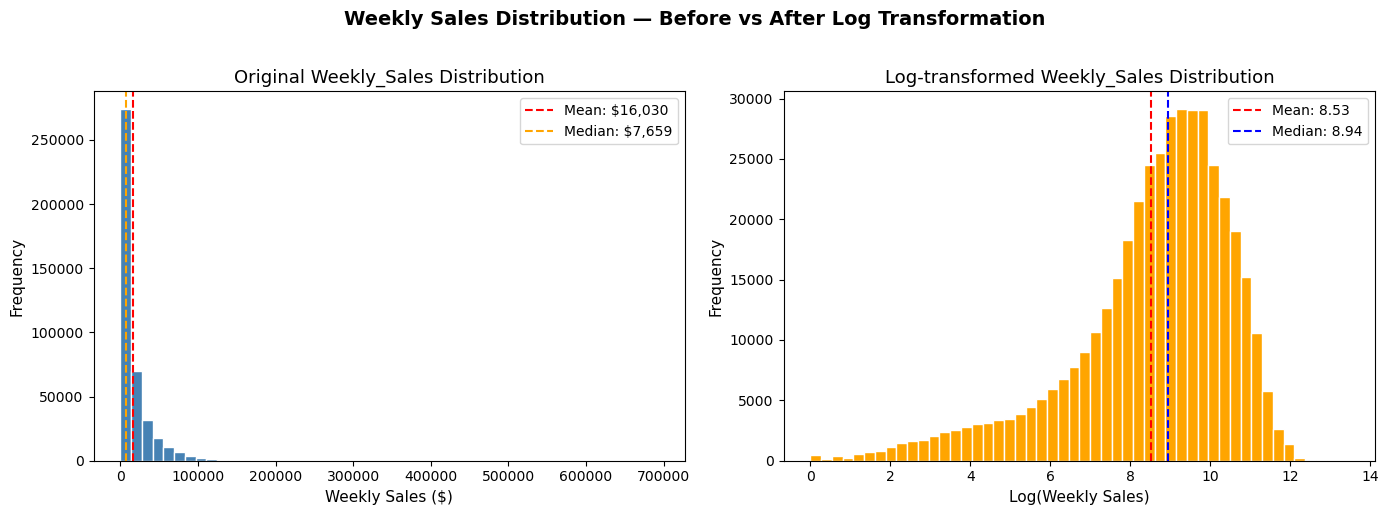

In [26]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================
# Left - original 
# ============================================
axes[0].hist(df_merged_final['Weekly_Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Original Weekly_Sales Distribution', fontsize=13)
axes[0].set_xlabel('Weekly Sales ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].axvline(df_merged_final['Weekly_Sales'].mean(), color='red', linestyle='--', label=f"Mean: ${df_merged_final['Weekly_Sales'].mean():,.0f}")
axes[0].axvline(df_merged_final['Weekly_Sales'].median(), color='orange', linestyle='--', label=f"Median: ${df_merged_final['Weekly_Sales'].median():,.0f}")
axes[0].legend()

# ============================================
# Right — Log 
# ============================================
log_sales = np.log1p(df_merged_final['Weekly_Sales'])
axes[1].hist(log_sales, bins=50, color='orange', edgecolor='white')
axes[1].set_title('Log-transformed Weekly_Sales Distribution', fontsize=13)
axes[1].set_xlabel('Log(Weekly Sales)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].axvline(log_sales.mean(), color='red', linestyle='--', label=f"Mean: {log_sales.mean():.2f}")
axes[1].axvline(log_sales.median(), color='blue', linestyle='--', label=f"Median: {log_sales.median():.2f}")
axes[1].legend()

plt.suptitle('Weekly Sales Distribution — Before vs After Log Transformation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# Apply log transformation to Weekly_Sales and save as a new column
df_merged_final['Weekly_Sales_log'] = np.log1p(df_merged_final['Weekly_Sales'])

# Check the result
print(df_merged_final[['Weekly_Sales', 'Weekly_Sales_log']].head(10))

   Weekly_Sales  Weekly_Sales_log
0      24924.50         10.123647
1      50605.27         10.831831
2      13740.12          9.528148
3      39954.04         10.595510
4      32229.38         10.380665
5       5749.03          8.656960
6      21084.08          9.956321
7      40129.01         10.599880
8      16930.99          9.736960
9      30721.50         10.332751


In [28]:
print(f"Original Weekly_Sales   — Mean: ${df_merged_final['Weekly_Sales'].mean():,.0f}    Max: ${df_merged_final['Weekly_Sales'].max():,.0f}")
print(f"Log Weekly_Sales    — Mean: {df_merged_final['Weekly_Sales_log'].mean():.2f}    Max: {df_merged_final['Weekly_Sales_log'].max():.2f}")

Original Weekly_Sales   — Mean: $16,030    Max: $693,099
Log Weekly_Sales    — Mean: 8.53    Max: 13.45


### Check the final dataset

In [29]:
df_merged_final

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size,Dept,Weekly_Sales,Weekly_Sales_log
0,1,05/02/2010,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,8.106,False,A,151315,1,24924.50,10.123647
1,1,05/02/2010,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,8.106,False,A,151315,2,50605.27,10.831831
2,1,05/02/2010,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,8.106,False,A,151315,3,13740.12,9.528148
3,1,05/02/2010,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,8.106,False,A,151315,4,39954.04,10.595510
4,1,05/02/2010,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,8.106,False,A,151315,5,32229.38,10.380665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,26/10/2012,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,False,B,118221,93,2487.80,7.819556
421566,45,26/10/2012,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,False,B,118221,94,5203.31,8.557242
421567,45,26/10/2012,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,False,B,118221,95,56017.47,10.933437
421568,45,26/10/2012,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,False,B,118221,97,6817.48,8.827392


In [30]:
df_merged_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 420285 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Store             420285 non-null  int64  
 1   Date              420285 non-null  object 
 2   Temperature       420285 non-null  float64
 3   Fuel_Price        420285 non-null  float64
 4   MarkDown1         420285 non-null  float64
 5   MarkDown2         420285 non-null  float64
 6   MarkDown3         420285 non-null  float64
 7   MarkDown4         420285 non-null  float64
 8   MarkDown5         420285 non-null  float64
 9   CPI               420285 non-null  float64
 10  Unemployment      420285 non-null  float64
 11  IsHoliday         420285 non-null  bool   
 12  Type              420285 non-null  object 
 13  Size              420285 non-null  int64  
 14  Dept              420285 non-null  int64  
 15  Weekly_Sales      420285 non-null  float64
 16  Weekly_Sales_log  420285 

## 3. Feature Engineering

In [31]:
from sklearn.preprocessing import LabelEncoder
# ============================================
# 1. Extract time features from Date
# ============================================

# Convert Date column to datetime format first
df_merged_final['Date'] = pd.to_datetime(df_merged_final['Date'], dayfirst=True)

# Confirm the format is correct
print(df_merged_final['Date'].dtype)  # Should display datetime64[ns]

# 1. Extract time features from Date
df_merged_final['Year'] = df_merged_final['Date'].dt.year
df_merged_final['Month'] = df_merged_final['Date'].dt.month
df_merged_final['Week'] = df_merged_final['Date'].dt.isocalendar().week.astype(int)

# 2. Encode IsHoliday (True/False → 1/0)
df_merged_final['IsHoliday'] = df_merged_final['IsHoliday'].astype(int)

# 3. Encode Type (A / B / C → 0 / 1 / 2)
le = LabelEncoder()
df_merged_final['Type_encoded'] = le.fit_transform(df_merged_final['Type'])

# Verify results
print(df_merged_final[['Date', 'Year', 'Month', 'Week', 'IsHoliday', 'Type', 'Type_encoded']].head(10))
print(f"\nTotal columns after adding new features: {df_merged_final.shape[1]}")

datetime64[ns]
        Date  Year  Month  Week  IsHoliday Type  Type_encoded
0 2010-02-05  2010      2     5          0    A             0
1 2010-02-05  2010      2     5          0    A             0
2 2010-02-05  2010      2     5          0    A             0
3 2010-02-05  2010      2     5          0    A             0
4 2010-02-05  2010      2     5          0    A             0
5 2010-02-05  2010      2     5          0    A             0
6 2010-02-05  2010      2     5          0    A             0
7 2010-02-05  2010      2     5          0    A             0
8 2010-02-05  2010      2     5          0    A             0
9 2010-02-05  2010      2     5          0    A             0

Total columns after adding new features: 21


In [32]:
# ============================================
# 2. Encode IsHoliday (True/False → 1/0)
# ============================================
df_merged_final['IsHoliday'] = df_merged_final['IsHoliday'].astype(int)


In [33]:
# ============================================
# 3. Encode Type (A / B / C → 0 / 1 / 2)
# ============================================
le = LabelEncoder()
df_merged_final['Type_encoded'] = le.fit_transform(df_merged_final['Type'])


In [34]:
# ============================================
# Verify results
# ============================================
print(df_merged_final[['Date', 'Year', 'Month', 'Week', 'IsHoliday', 'Type', 'Type_encoded']].head(10))
print(f"\nTotal columns after adding new features: {df_merged_final.shape[1]}")

        Date  Year  Month  Week  IsHoliday Type  Type_encoded
0 2010-02-05  2010      2     5          0    A             0
1 2010-02-05  2010      2     5          0    A             0
2 2010-02-05  2010      2     5          0    A             0
3 2010-02-05  2010      2     5          0    A             0
4 2010-02-05  2010      2     5          0    A             0
5 2010-02-05  2010      2     5          0    A             0
6 2010-02-05  2010      2     5          0    A             0
7 2010-02-05  2010      2     5          0    A             0
8 2010-02-05  2010      2     5          0    A             0
9 2010-02-05  2010      2     5          0    A             0

Total columns after adding new features: 21


In [35]:
# ============================================
# Define feature columns (X)
# ============================================
feature_cols = [
    'Store', 'Dept', 'Year', 'Month', 'Week',
    'IsHoliday', 'Type_encoded', 'Size',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
]

X = df_merged_final[feature_cols]

# ============================================
# Define target variable (y)
# ============================================
y = df_merged_final['Weekly_Sales_log']

# ============================================
# Verify results
# ============================================
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature columns: {feature_cols}")
print(f"\nFirst 5 rows of X:")
print(X.head())
print(f"\nFirst 5 values of y:")
print(y.head())

X shape: (420285, 17)
y shape: (420285,)

Feature columns: ['Store', 'Dept', 'Year', 'Month', 'Week', 'IsHoliday', 'Type_encoded', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

First 5 rows of X:
   Store  Dept  Year  Month  Week  IsHoliday  Type_encoded    Size  \
0      1     1  2010      2     5          0             0  151315   
1      1     2  2010      2     5          0             0  151315   
2      1     3  2010      2     5          0             0  151315   
3      1     4  2010      2     5          0             0  151315   
4      1     5  2010      2     5          0             0  151315   

   Temperature  Fuel_Price         CPI  Unemployment  MarkDown1  MarkDown2  \
0        42.31       2.572  211.096358         8.106        0.0        0.0   
1        42.31       2.572  211.096358         8.106        0.0        0.0   
2        42.31       2.572  211.096358         8.106        0.0      

In [36]:
# ============================================
# Step 6: Split by time (not random!)
# ============================================
train_mask = df_merged_final['Year'] < 2012
test_mask  = df_merged_final['Year'] >= 2012

X_train = X[train_mask]
X_test  = X[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]

# Verify
print(f"X_train: {X_train.shape}  — period: {df_merged_final[train_mask]['Date'].min().date()} to {df_merged_final[train_mask]['Date'].max().date()}")
print(f"X_test:  {X_test.shape}  — period: {df_merged_final[test_mask]['Date'].min().date()} to {df_merged_final[test_mask]['Date'].max().date()}")

X_train: (293259, 17)  — period: 2010-02-05 to 2011-12-30
X_test:  (127026, 17)  — period: 2012-01-06 to 2012-10-26


## 4. Train the model 

#### Reason to choose these features: I selected these features based on both business logic and domain knowledge. Temporal features capture seasonality, store attributes reflect structural differences, macroeconomic indicators represent external demand drivers, and MarkDown variables quantify the direct impact of promotional activities on sales

In [37]:
# ============================================
# Step 7: Train XGBoost
# ============================================
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model training complete! ✅")

Model training complete! ✅


### Plot the important features 

         Feature  Importance
1           Dept    0.375189
6   Type_encoded    0.228243
7           Size    0.168114
0          Store    0.065156
2           Year    0.028174
4           Week    0.027731
3          Month    0.026939
11  Unemployment    0.019675
10           CPI    0.019550
14     MarkDown3    0.009330
9     Fuel_Price    0.009028
8    Temperature    0.007429
5      IsHoliday    0.004007
13     MarkDown2    0.003032
12     MarkDown1    0.002837
15     MarkDown4    0.002828
16     MarkDown5    0.002736


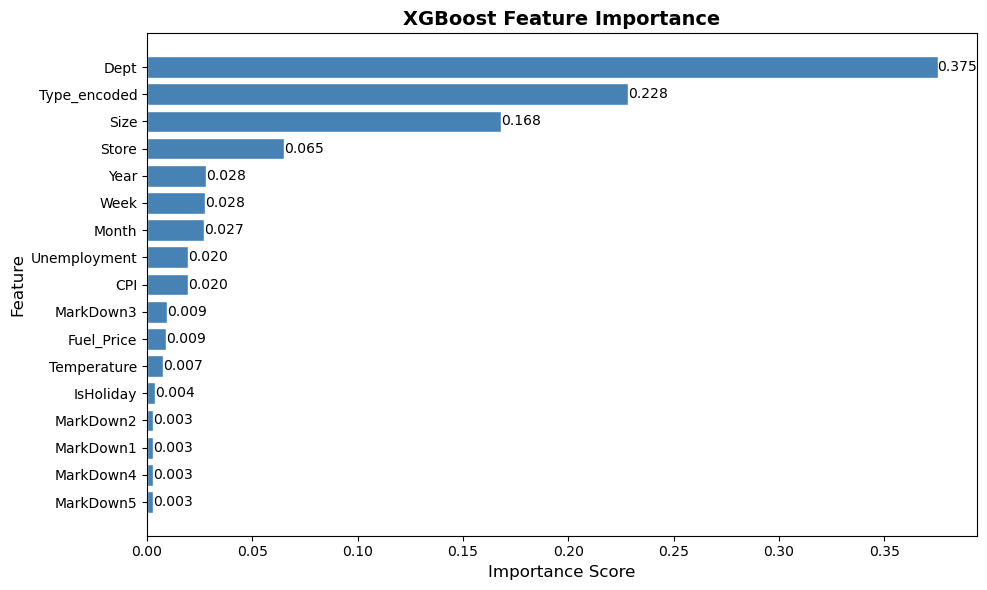

In [38]:
# Important features 
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance)

# Then plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color='steelblue',
    edgecolor='white'
)
for index, value in enumerate(feature_importance['Importance']):
    plt.text(value, index, f'{value:.3f}', va='center', fontsize=10)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Evalute the model 

In [39]:
from sklearn.metrics import mean_absolute_error, r2_score

# ============================================
# Step 8: Evaluate model
# ============================================
# Make predictions on test set
y_pred_log = model.predict(X_test)

# Convert log predictions back to original scale
y_pred   = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

# Calculate WMAE (Walmart official metric)
test_weights = df_merged_final[test_mask]['IsHoliday'].apply(lambda x: 5 if x == 1 else 1)
wmae = np.sum(test_weights * np.abs(y_actual - y_pred)) / np.sum(test_weights)

# Calculate MAE
mae = mean_absolute_error(y_actual, y_pred)

# Calculate MAPE (exclude zeros)
mask = y_actual > 0
mape = np.mean(np.abs((y_actual[mask] - y_pred[mask]) / y_actual[mask])) * 100

# Calculate R²
r2 = r2_score(y_actual, y_pred)

print(f"=== Step 8: Model Evaluation ===")
print(f"MAE   (Mean Absolute Error):            ${mae:,.2f}")
print(f"WMAE  (Weighted MAE):                   ${wmae:,.2f}")
print(f"MAPE  (Mean Absolute Percentage Error):  {mape:.2f}%")
print(f"R²    (R-squared Score):                 {r2:.4f}")

# Sample predictions vs actual
comparison = pd.DataFrame({
    'Actual Sales':    y_actual[:5].values,
    'Predicted Sales': y_pred[:5],
    'Difference':      np.abs(y_actual[:5].values - y_pred[:5])
}).round(2)
print(f"\nSample predictions vs actual:")
print(comparison)

=== Step 8: Model Evaluation ===
MAE   (Mean Absolute Error):            $3,243.63
WMAE  (Weighted MAE):                   $3,270.36
MAPE  (Mean Absolute Percentage Error):  515.34%
R²    (R-squared Score):                 0.9157

Sample predictions vs actual:
   Actual Sales  Predicted Sales  Difference
0      16567.69     17578.849609     1011.16
1      44481.38     42058.398438     2422.98
2      13926.04     13107.250000      818.79
3      40925.76     27437.640625    13488.12
4      23105.81     22616.880859      488.93


Overall, my model performs well with an R² of 0.916 and a WMAE of $3,270. The main area for improvement is capturing extreme sales spikes during promotional and holiday periods, which could be addressed by adding lag features or store-department interaction terms.

The MAPE of 515% is inflated by departments with near-zero weekly sales, where even small absolute errors produce large percentage errors. This is a known limitation of MAPE as a metric and does not reflect the true model quality.

In [40]:
# ============================================
# Step 9: Generate submission file
# ============================================

# 1. Make predictions on full training data
y_full_pred_log = model.predict(X)
y_full_pred = np.expm1(y_full_pred_log)

# 2. Create Id column (Store_Dept_Date format)
df_merged_final['Id'] = (
    df_merged_final['Store'].astype(str) + '_' +
    df_merged_final['Dept'].astype(str) + '_' +
    df_merged_final['Date'].dt.strftime('%Y-%m-%d')
)

# 3. Create submission dataframe
df_merged_final['Weekly_Sales_Predicted'] = y_full_pred
submission = df_merged_final[['Id', 'Weekly_Sales_Predicted']].rename(
    columns={'Weekly_Sales_Predicted': 'Weekly_Sales'}
)

# 4. Verify format
print(submission.head(10))
print(f"\nTotal rows: {submission.shape[0]}")

# 5. Save to CSV
submission.to_csv('submission.csv', index=False)
print("\nsubmission.csv saved successfully! ✅")

                Id  Weekly_Sales
0   1_1_2010-02-05  25908.228516
1   1_2_2010-02-05  52798.808594
2   1_3_2010-02-05  12910.758789
3   1_4_2010-02-05  34184.507812
4   1_5_2010-02-05  27795.013672
5   1_6_2010-02-05   5752.557617
6   1_7_2010-02-05  24869.462891
7   1_8_2010-02-05  39197.214844
8   1_9_2010-02-05  22766.636719
9  1_10_2010-02-05  24544.457031

Total rows: 420285

submission.csv saved successfully! ✅
